In [72]:
# import libraries 
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


In [73]:
df=pd.read_csv('Exam_Score_Prediction.csv')
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [74]:
df.shape

(20000, 13)

In [75]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [77]:
# Show rows that contain at least one null
df[df.isnull().any(axis=1)]

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score


In [78]:
# Show rows where all columns are null
df[df.isnull().all(axis=1)]

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score


In [79]:
df.isna().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [80]:
df.drop(['student_id','age'],axis=1,inplace=True)

In [81]:
df.columns

Index(['gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [82]:
df['gender'].value_counts()

gender
other     6726
male      6695
female    6579
Name: count, dtype: int64

#### Function to replace `other` with 60% `male` and 40% `female`

In [83]:
def replace_other_gender(df, column='gender', p_male=0.6, p_female=0.4):
    mask = df[column] == 'other'
    df.loc[mask, column] = np.random.choice(
        ['male', 'female'],
        size=mask.sum(), # how many "other" entries exist
        p=[p_male, p_female]
    )
    return df

In [84]:
import numpy as np

def replace_other_gender_deterministic(df, column='gender', male_ratio=0.6):
    # 1. Get indices of "other"
    other_index = df[df[column] == 'other'].index
    
    # 2. Shuffle them randomly
    other_index = np.random.permutation(other_index)
    
    # 3. Calculate how many should become male/female
    n_other = len(other_index)
    n_male = int(n_other * male_ratio)      # 60% male
    n_female = n_other - n_male             # 40% female
    
    # 4. Assign genders
    df.loc[other_index[:n_male], column] = 'male'
    df.loc[other_index[n_male:], column] = 'female'
    
    return df


In [85]:
df[df['gender'] == 'other']

,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
1,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
3,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
8,other,bca,2.89,92.0,yes,6.6,poor,self-study,low,easy,44.9
15,other,bba,4.84,99.4,yes,7.3,average,coaching,high,moderate,98.5
21,other,ba,1.70,70.4,yes,9.8,good,mixed,low,easy,52.1
...,...,...,...,...,...,...,...,...,...,...,...
19989,other,diploma,2.10,60.9,yes,8.1,poor,self-study,low,hard,37.8
19991,other,bca,2.94,90.3,yes,4.5,average,online videos,medium,moderate,56.7
19994,other,diploma,3.04,80.7,yes,8.0,average,online videos,high,moderate,78.4
19995,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5


In [86]:
mask = df['gender'] == 'other'
mask

0        False
1         True
2        False
3         True
4        False
         ...  
19995     True
19996    False
19997     True
19998    False
19999    False
Name: gender, Length: 20000, dtype: bool

In [87]:
mask.sum()

np.int64(6726)

In [88]:
df = replace_other_gender_deterministic(df)
df['gender'].value_counts()

gender
male      10730
female     9270
Name: count, dtype: int64

In [89]:
df.head()

,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,male,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,male,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [90]:
df['course'].value_counts()

course
bca        2902
ba         2896
b.sc       2878
b.com      2864
bba        2836
diploma    2826
b.tech     2798
Name: count, dtype: int64

In [91]:
df['internet_access'].value_counts()

internet_access
yes    16988
no      3012
Name: count, dtype: int64

In [92]:
df['sleep_quality'].value_counts()

sleep_quality
average    6694
poor       6687
good       6619
Name: count, dtype: int64

In [93]:
df['study_method'].value_counts()

study_method
self-study       4079
online videos    4069
coaching         4036
group study      3922
mixed            3894
Name: count, dtype: int64

In [94]:
df['facility_rating'].value_counts() 

facility_rating
medium    6760
low       6638
high      6602
Name: count, dtype: int64

In [95]:
df['exam_difficulty'].value_counts()

exam_difficulty
moderate    9878
easy        6141
hard        3981
Name: count, dtype: int64

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            20000 non-null  object 
 1   course            20000 non-null  object 
 2   study_hours       20000 non-null  float64
 3   class_attendance  20000 non-null  float64
 4   internet_access   20000 non-null  object 
 5   sleep_hours       20000 non-null  float64
 6   sleep_quality     20000 non-null  object 
 7   study_method      20000 non-null  object 
 8   facility_rating   20000 non-null  object 
 9   exam_difficulty   20000 non-null  object 
 10  exam_score        20000 non-null  float64
dtypes: float64(4), object(7)
memory usage: 1.7+ MB


In [97]:
number_cols=df.select_dtypes(include='number').columns.tolist()
string_cols=df.select_dtypes(include='object').columns.tolist()

In [98]:
number_cols

['study_hours', 'class_attendance', 'sleep_hours', 'exam_score']

In [99]:
string_cols

['gender',
 'course',
 'internet_access',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty']

In [100]:
# ecode the string labels
encoders={}
for col in string_cols:
    le=LabelEncoder()
    df[col+'_encoded']=le.fit_transform(df[col])
    encoders[col]=le

In [101]:
df

,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,gender_encoded,course_encoded,internet_access_encoded,sleep_quality_encoded,study_method_encoded,facility_rating_encoded,exam_difficulty_encoded
0,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9,1,6,1,2,0,1,1
1,male,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8,1,5,1,0,3,2,2
2,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3,1,1,1,2,0,0,2
3,male,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7,1,6,1,0,3,1,2
4,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7,0,6,1,2,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,male,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5,1,4,1,1,4,1,0
19996,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9,1,0,0,0,0,2,2
19997,female,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5,0,6,1,2,1,1,0
19998,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0,1,4,0,1,4,2,2


In [102]:
for col,le in encoders.items():
    mapping=dict(zip(le.classes_,le.transform(le.classes_)))
    print(f"Mapping for {col}:{mapping}")

Mapping for gender:{'female': np.int64(0), 'male': np.int64(1)}
Mapping for course:{'b.com': np.int64(0), 'b.sc': np.int64(1), 'b.tech': np.int64(2), 'ba': np.int64(3), 'bba': np.int64(4), 'bca': np.int64(5), 'diploma': np.int64(6)}
Mapping for internet_access:{'no': np.int64(0), 'yes': np.int64(1)}
Mapping for sleep_quality:{'average': np.int64(0), 'good': np.int64(1), 'poor': np.int64(2)}
Mapping for study_method:{'coaching': np.int64(0), 'group study': np.int64(1), 'mixed': np.int64(2), 'online videos': np.int64(3), 'self-study': np.int64(4)}
Mapping for facility_rating:{'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}
Mapping for exam_difficulty:{'easy': np.int64(0), 'hard': np.int64(1), 'moderate': np.int64(2)}


In [103]:
encoders.items()

dict_items([('gender', LabelEncoder()), ('course', LabelEncoder()), ('internet_access', LabelEncoder()), ('sleep_quality', LabelEncoder()), ('study_method', LabelEncoder()), ('facility_rating', LabelEncoder()), ('exam_difficulty', LabelEncoder())])

In [104]:
df['gender'].value_counts()

gender
male      10730
female     9270
Name: count, dtype: int64

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   20000 non-null  object 
 1   course                   20000 non-null  object 
 2   study_hours              20000 non-null  float64
 3   class_attendance         20000 non-null  float64
 4   internet_access          20000 non-null  object 
 5   sleep_hours              20000 non-null  float64
 6   sleep_quality            20000 non-null  object 
 7   study_method             20000 non-null  object 
 8   facility_rating          20000 non-null  object 
 9   exam_difficulty          20000 non-null  object 
 10  exam_score               20000 non-null  float64
 11  gender_encoded           20000 non-null  int64  
 12  course_encoded           20000 non-null  int64  
 13  internet_access_encoded  20000 non-null  int64  
 14  sleep_quality_encoded 

In [106]:
df.drop(['gender','course','internet_access','sleep_quality','study_method','facility_rating','exam_difficulty'],axis=1,inplace=True)

In [107]:
df.columns

Index(['study_hours', 'class_attendance', 'sleep_hours', 'exam_score',
       'gender_encoded', 'course_encoded', 'internet_access_encoded',
       'sleep_quality_encoded', 'study_method_encoded',
       'facility_rating_encoded', 'exam_difficulty_encoded'],
      dtype='object')

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   study_hours              20000 non-null  float64
 1   class_attendance         20000 non-null  float64
 2   sleep_hours              20000 non-null  float64
 3   exam_score               20000 non-null  float64
 4   gender_encoded           20000 non-null  int64  
 5   course_encoded           20000 non-null  int64  
 6   internet_access_encoded  20000 non-null  int64  
 7   sleep_quality_encoded    20000 non-null  int64  
 8   study_method_encoded     20000 non-null  int64  
 9   facility_rating_encoded  20000 non-null  int64  
 10  exam_difficulty_encoded  20000 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 1.7 MB


In [109]:
corr=df.corr()
corr

,study_hours,class_attendance,sleep_hours,exam_score,gender_encoded,course_encoded,internet_access_encoded,sleep_quality_encoded,study_method_encoded,facility_rating_encoded,exam_difficulty_encoded
study_hours,1.000000,-0.001645,-0.004533,0.717788,0.000768,-0.004294,-0.012706,0.005389,-0.001920,0.009842,0.005630
class_attendance,-0.001645,1.000000,0.007187,0.308850,-0.008412,-0.004932,0.006729,0.003473,-0.002734,-0.005879,-0.005156
sleep_hours,-0.004533,0.007187,1.000000,0.133222,-0.002127,0.002474,-0.010066,-0.010000,0.001744,0.003587,0.000007
exam_score,0.717788,0.308850,0.133222,1.000000,-0.005563,-0.000448,-0.007826,-0.099725,-0.154610,-0.071879,0.003432
gender_encoded,0.000768,-0.008412,-0.002127,-0.005563,1.000000,0.007573,0.001945,0.001196,0.005358,0.005181,0.002532
course_encoded,-0.004294,-0.004932,0.002474,-0.000448,0.007573,1.000000,-0.006307,0.005533,-0.008628,0.003464,0.003149
internet_access_encoded,-0.012706,0.006729,-0.010066,-0.007826,0.001945,-0.006307,1.000000,-0.004282,0.012887,0.004754,-0.004186
sleep_quality_encoded,0.005389,0.003473,-0.010000,-0.099725,0.001196,0.005533,-0.004282,1.000000,0.008127,-0.003511,-0.004169
study_method_encoded,-0.001920,-0.002734,0.001744,-0.154610,0.005358,-0.008628,0.012887,0.008127,1.000000,-0.001155,0.003112
facility_rating_encoded,0.009842,-0.005879,0.003587,-0.071879,0.005181,0.003464,0.004754,-0.003511,-0.001155,1.000000,0.007163


In [110]:
## Duplicate records
df[df.duplicated()]

,study_hours,class_attendance,sleep_hours,exam_score,gender_encoded,course_encoded,internet_access_encoded,sleep_quality_encoded,study_method_encoded,facility_rating_encoded,exam_difficulty_encoded


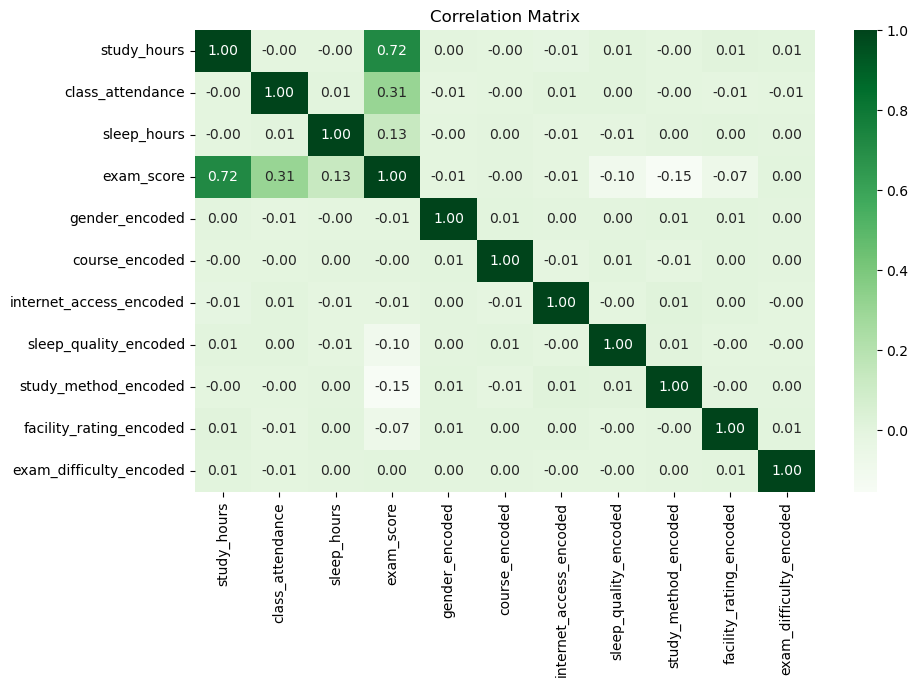

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='Greens',fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [112]:
# for column in df.columns:
#     sns.histplot(df[column],kde=True)

In [113]:
# sns.pairplot(df)
# plt.show()

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   study_hours              20000 non-null  float64
 1   class_attendance         20000 non-null  float64
 2   sleep_hours              20000 non-null  float64
 3   exam_score               20000 non-null  float64
 4   gender_encoded           20000 non-null  int64  
 5   course_encoded           20000 non-null  int64  
 6   internet_access_encoded  20000 non-null  int64  
 7   sleep_quality_encoded    20000 non-null  int64  
 8   study_method_encoded     20000 non-null  int64  
 9   facility_rating_encoded  20000 non-null  int64  
 10  exam_difficulty_encoded  20000 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 1.7 MB


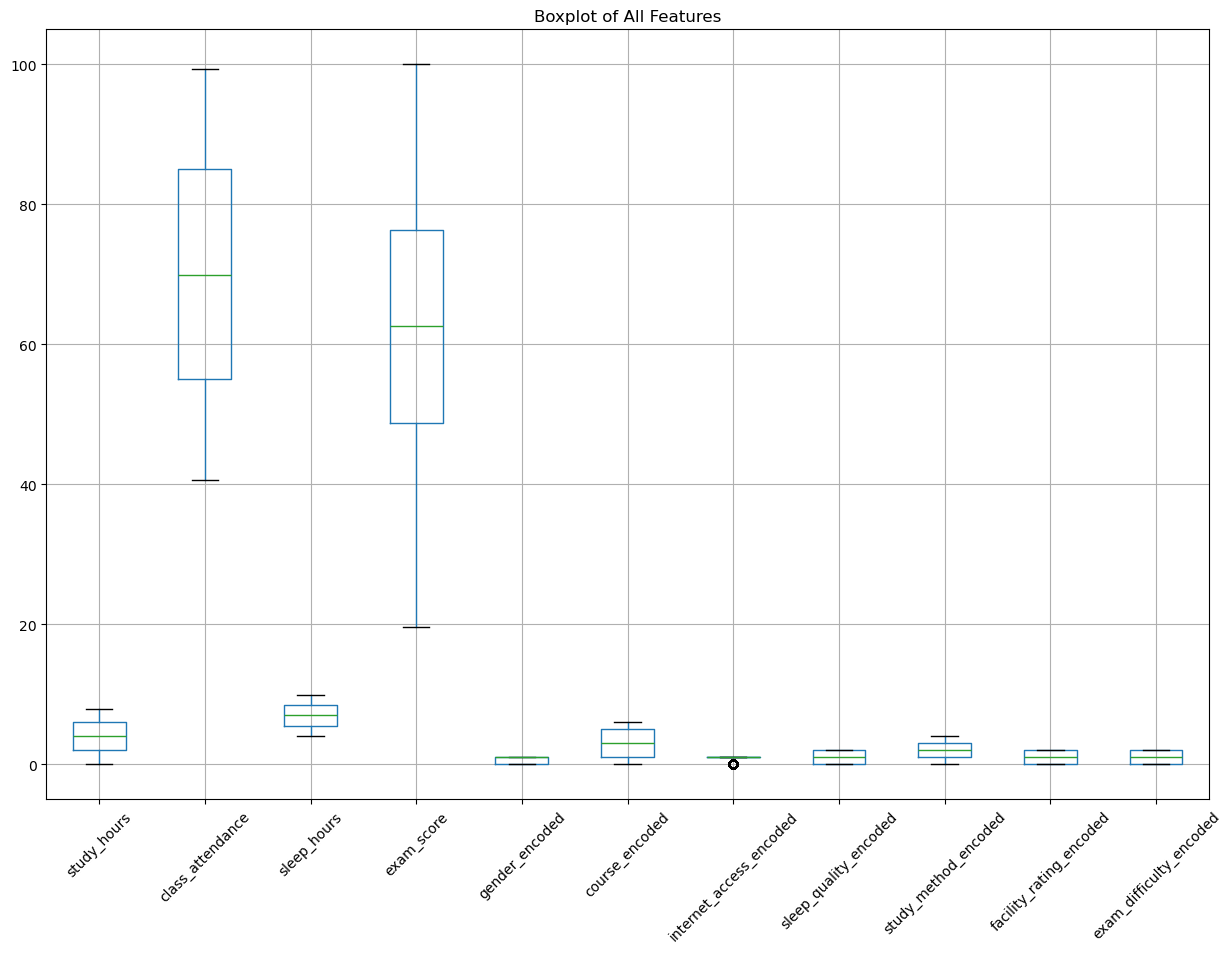

In [115]:
plt.figure(figsize=(15, 10))
df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of All Features")
plt.show()

In [116]:
# plt.figure(figsize=(15, 10))
# box = df.boxplot(patch_artist=True)

# # Color all boxes
# for patch in box['boxes']:
#     patch.set_facecolor('lightblue')   # change color
#     patch.set_edgecolor('blue')        # border color

# plt.xticks(rotation=45)
# plt.title("Boxplot of All Features")
# plt.show()

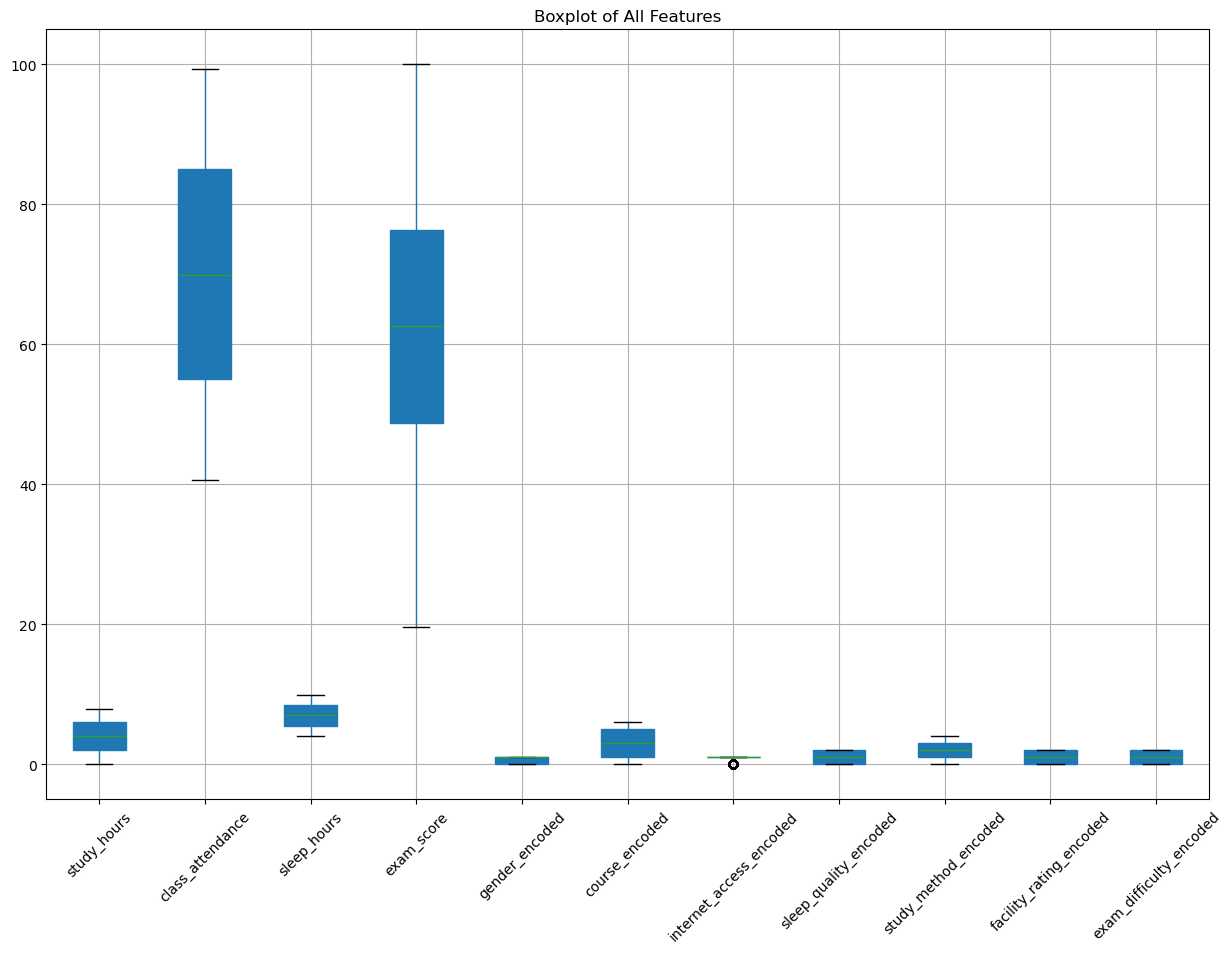

In [117]:
plt.figure(figsize=(15, 10))

ax = df.boxplot(patch_artist=True)  # return Axes object

# Loop through each box in the plot
for patch in ax.artists:
    patch.set_facecolor('lightblue')   # box color
    patch.set_edgecolor('blue')        # border color
    patch.set_alpha(0.7)               # transparency (optional)

plt.xticks(rotation=45)
plt.title("Boxplot of All Features")
plt.show()

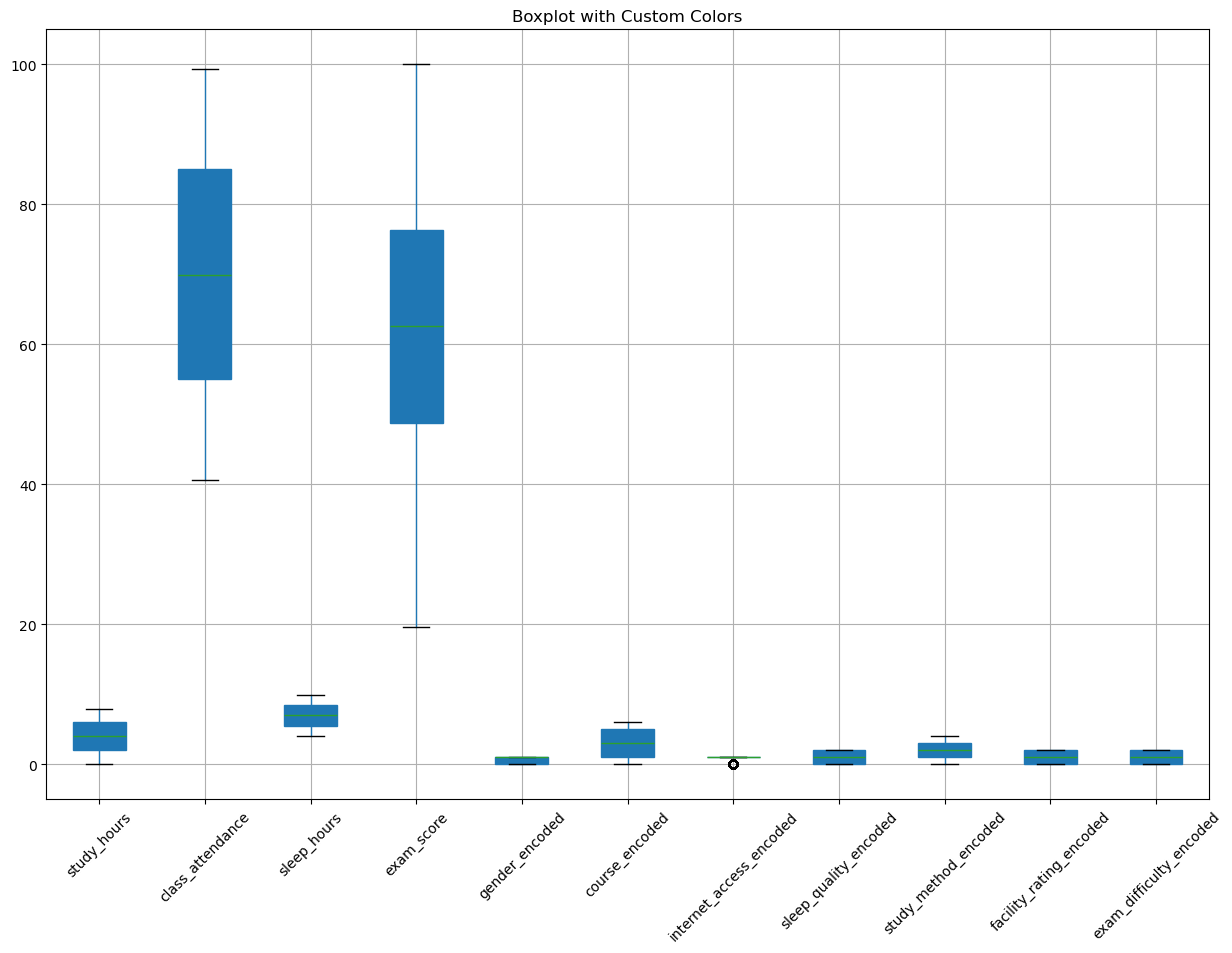

In [118]:
colors = ['skyblue', 'lightgreen', 'salmon', 'violet', 'gold',
          'turquoise', 'plum', 'khaki', 'orange', 'lightpink', 'cyan']

plt.figure(figsize=(15, 10))
ax = df.boxplot(patch_artist=True)

for patch, color in zip(ax.artists, colors):
    patch.set_facecolor(color)

plt.xticks(rotation=45)
plt.title("Boxplot with Custom Colors")
plt.show()


In [119]:
df.columns

Index(['study_hours', 'class_attendance', 'sleep_hours', 'exam_score',
       'gender_encoded', 'course_encoded', 'internet_access_encoded',
       'sleep_quality_encoded', 'study_method_encoded',
       'facility_rating_encoded', 'exam_difficulty_encoded'],
      dtype='object')

In [120]:
group=df.groupby('gender_encoded',as_index=False)['exam_score'].mean()
group

,gender_encoded,exam_score
0,0,62.626387
1,1,62.415461


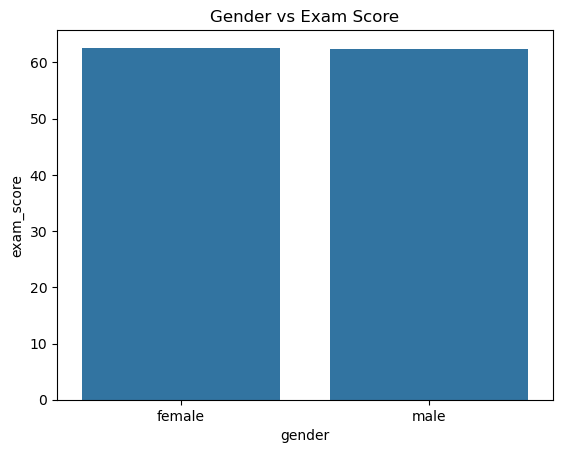

In [121]:
# Map the encoded column back to labels before plotting
gender_map = {0: "female", 1: "male"}
group["gender"] = group["gender_encoded"].map(gender_map)
sns.barplot(data=group, x="gender", y="exam_score")
plt.title("Gender vs Exam Score")
plt.show()


In [122]:
group

,gender_encoded,exam_score,gender
0,0,62.626387,female
1,1,62.415461,male


In [123]:
grouped = df.groupby(['course_encoded', 'gender_encoded'], as_index=False)['exam_score'].mean()
grouped

,course_encoded,gender_encoded,exam_score
0,0,0,61.975986
1,0,1,62.655304
2,1,0,63.218498
3,1,1,62.306332
4,2,0,63.060752
5,2,1,62.277653
6,3,0,61.846839
7,3,1,62.348488
8,4,0,63.630485
9,4,1,62.359338


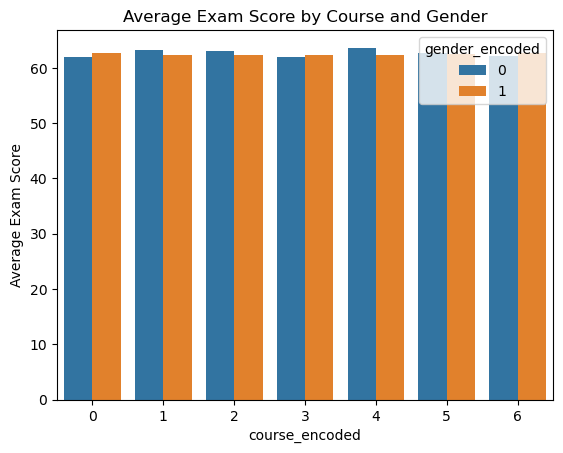

In [124]:
sns.barplot(data=grouped, x='course_encoded', y='exam_score', hue='gender_encoded')
plt.title("Average Exam Score by Course and Gender")
plt.ylabel("Average Exam Score")
plt.show()

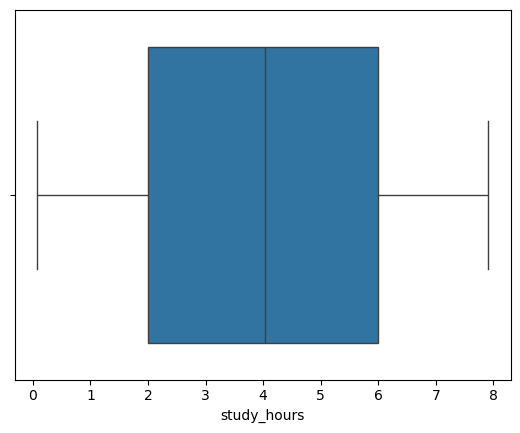

In [125]:
sns.boxplot(x=df['study_hours'])
plt.show()

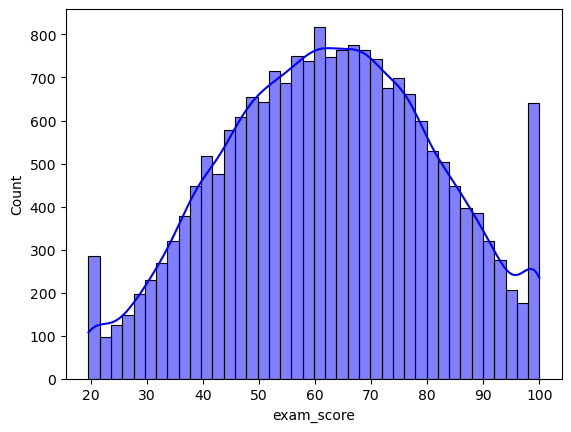

In [126]:
sns.histplot(df['exam_score'], kde=True,color='blue')
plt.show()

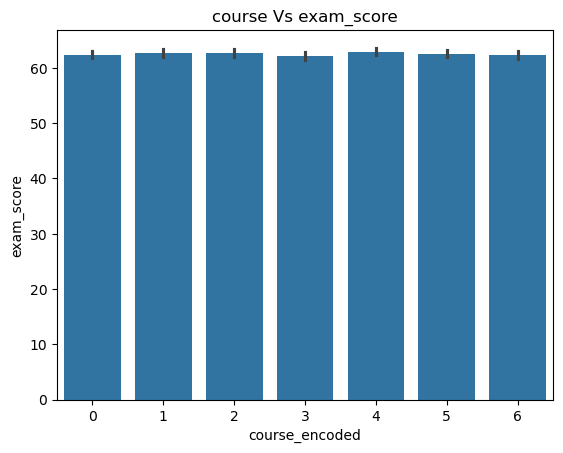

In [127]:
sns.barplot(data=df,x='course_encoded',y='exam_score')
plt.title('course Vs exam_score')
plt.show()

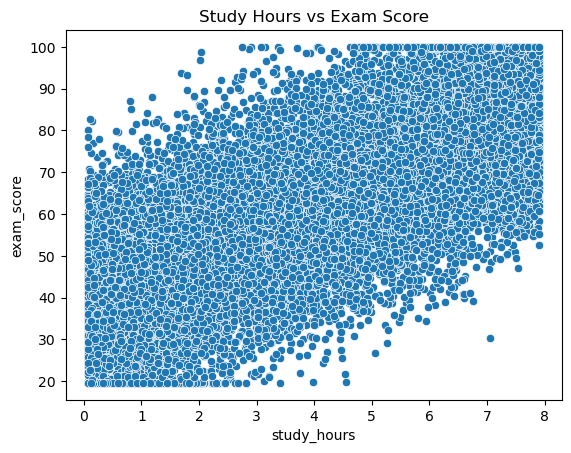

In [128]:
# colors = ['green']
sns.scatterplot(data=df, x='study_hours', y='exam_score')
plt.title("Study Hours vs Exam Score")
plt.show()

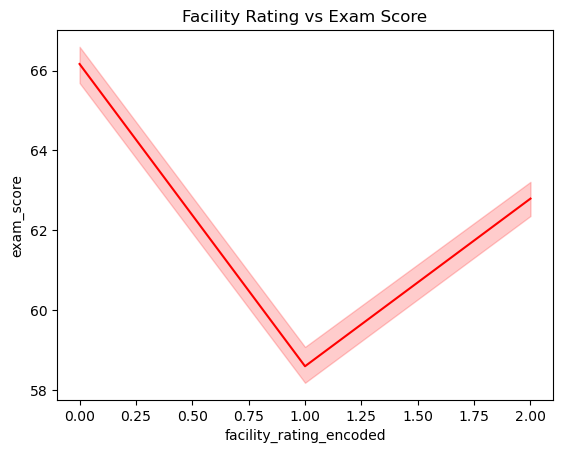

In [129]:
sns.lineplot(data=df, x='facility_rating_encoded', y='exam_score',color='red')
plt.title("Facility Rating vs Exam Score")
plt.show()

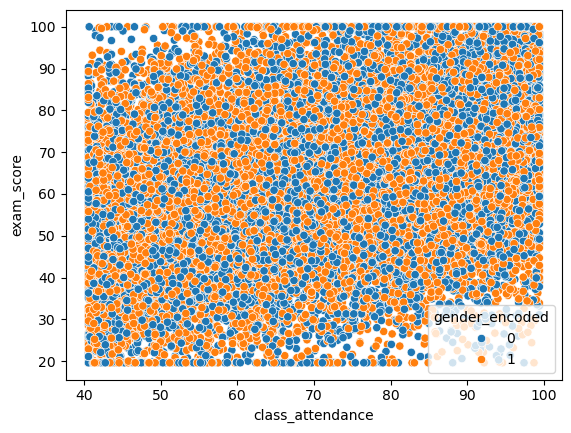

In [130]:
sns.scatterplot(x='class_attendance',y='exam_score',hue='gender_encoded',data=df) # 1 male and 0 female
plt.show()

In [131]:
df_copy=df

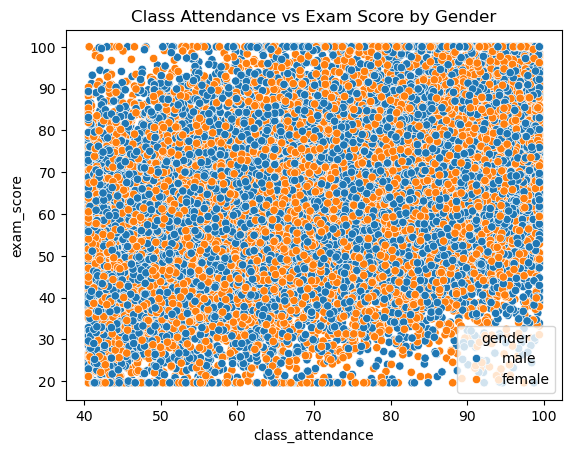

In [132]:
gender_map = {0: "female", 1: "male"}
df_copy["gender"] = df_copy["gender_encoded"].map(gender_map)

sns.scatterplot(
    x='class_attendance',
    y='exam_score',
    hue='gender',
    data=df_copy
)
plt.title("Class Attendance vs Exam Score by Gender")
plt.show()


In [133]:
df

,study_hours,class_attendance,sleep_hours,exam_score,gender_encoded,course_encoded,internet_access_encoded,sleep_quality_encoded,study_method_encoded,facility_rating_encoded,exam_difficulty_encoded,gender
0,2.78,92.9,7.4,58.9,1,6,1,2,0,1,1,male
1,3.37,64.8,4.6,54.8,1,5,1,0,3,2,2,male
2,7.88,76.8,8.5,90.3,1,1,1,2,0,0,2,male
3,0.67,48.4,5.8,29.7,1,6,1,0,3,1,2,male
4,0.89,71.6,9.8,43.7,0,6,1,2,0,1,2,female
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,6.50,71.3,5.0,86.5,1,4,1,1,4,1,0,male
19996,3.71,41.6,5.9,60.9,1,0,0,0,0,2,2,male
19997,7.88,68.2,4.6,64.5,0,6,1,2,1,1,0,female
19998,4.60,76.3,6.1,79.0,1,4,0,1,4,2,2,male


In [134]:
df.columns

Index(['study_hours', 'class_attendance', 'sleep_hours', 'exam_score',
       'gender_encoded', 'course_encoded', 'internet_access_encoded',
       'sleep_quality_encoded', 'study_method_encoded',
       'facility_rating_encoded', 'exam_difficulty_encoded', 'gender'],
      dtype='object')

In [140]:
# Remove "_encoded" from column names
df.columns = df.columns.str.replace('_encoded', '', regex=False)

In [136]:
# df.info()

In [137]:
# Drop columdf = df.drop(df.columns[11], axis=1)
# df = df.drop(df.columns[11], axis=1)

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   study_hours              20000 non-null  float64
 1   class_attendance         20000 non-null  float64
 2   sleep_hours              20000 non-null  float64
 3   exam_score               20000 non-null  float64
 4   gender_encoded           20000 non-null  int64  
 5   course_encoded           20000 non-null  int64  
 6   internet_access_encoded  20000 non-null  int64  
 7   sleep_quality_encoded    20000 non-null  int64  
 8   study_method_encoded     20000 non-null  int64  
 9   facility_rating_encoded  20000 non-null  int64  
 10  exam_difficulty_encoded  20000 non-null  int64  
 11  gender                   20000 non-null  object 
dtypes: float64(4), int64(7), object(1)
memory usage: 1.8+ MB


In [141]:
df = df.loc[:, ~df.columns.duplicated()]

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   study_hours       20000 non-null  float64
 1   class_attendance  20000 non-null  float64
 2   sleep_hours       20000 non-null  float64
 3   exam_score        20000 non-null  float64
 4   gender            20000 non-null  int64  
 5   course            20000 non-null  int64  
 6   internet_access   20000 non-null  int64  
 7   sleep_quality     20000 non-null  int64  
 8   study_method      20000 non-null  int64  
 9   facility_rating   20000 non-null  int64  
 10  exam_difficulty   20000 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 1.7 MB


In [143]:
# Save cleaned data to CSV
df.to_csv("cleaned_data.csv", index=False)